<a href="https://colab.research.google.com/github/Celestin25/student-dropout-app/blob/main/Final_Project_Student_Dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Student Dropout and Academic Success
## Data Science Final Project Masters in Collective Intelligence

| | |
|---|---|
| **Institution** | Université Mohammed VI Polytechnique (UM6P) |
| **Course** | Programming, Data Science & Statistics 2 |
| **Instructor** | Pr. Ikram Chairi |
| **Teaching Assistant** | Ayobami Emmanuel Omolusi |
| **Group members** | Celestin Hakorimana,Rim ABDELHAKMI,Mariam OUKADOUR |



---

## Abstract

Student dropout is a critical and costly challenge in higher education worldwide.
In this project we build a complete machine learning pipeline using **every technique covered during the semester**:
Recursive Feature Elimination (RFE), PCA, t-SNE, GLM Logistic Regression, Interaction Effects,
CART Decision Trees, and Ensemble Methods (Random Forest + Gradient Boosting).

We apply these methods to the **UCI Student Dropout dataset** (3,630 students) and show that
academic performance in the first two semesters is the dominant predictor of dropout risk,
achieving **ROC-AUC > 0.91** with the best ensemble model.

Dataset loads automatically from a public URL,no file upload needed.


Setup

In [ ]:
# Install packages (needed on Google Colab)
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    %pip install statsmodels ucimlrepo --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

%matplotlib inline

# Sklearn - preprocessing & pipelines
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# Sklearn - feature selection & extraction
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

# Sklearn - visualisation
from sklearn.manifold import TSNE

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Statistical GLM  (
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Interaction Effects & transformations
from scipy import stats
from scipy.stats import skew, boxcox
import scipy.stats as scipy_stats

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
sns.set_style("whitegrid")

print(" All packages imported successfully.")
print(f"   numpy {np.__version__}  |  pandas {pd.__version__}")
print(f"   Running on {'Google Colab' if IN_COLAB else 'local Jupyter / JupyterLab'}")


 All packages imported successfully.
   numpy 2.0.2  |  pandas 2.2.2
   Running on Google Colab


###  Mount Google Drive


In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")
# SAVE_PATH = "/content/drive/MyDrive/FinalProject/"
# import os; os.makedirs(SAVE_PATH, exist_ok=True)
# print("Drive mounted. Saving outputs to:", SAVE_PATH)


---
# Section 1 Define the Research Question

## 1.1 Problem Statement

University dropout has profound consequences for students, institutions, and society.
In Portugal, dropout rates exceed 20% in some fields. Machine learning offers a way to
identify at-risk students early enough to intervene.

## 1.2 Research Question

> *Can we **predict whether a university student will drop out or graduate** based on
> their demographic, socio-economic, and academic performance features?*

## 1.3 Why This is a Good Data Science Problem

- **Binary classification** exactly the setting for GLM, CART, and Ensemble methods.
- **Rich, structured dataset**  36 features covering multiple real-world dimensions.
- **High social impact**  early warning enables targeted institutional support.
- **Every course technique applies** this single dataset lets us demonstrate the full semester pipeline.

## 1.4 Dataset

| | |
|---|---|
| **Source** | UCI ML Repository  *Predict Students' Dropout and Academic Success* (ID 697) |
| **Reference** | Realinho et al. (2022), *Data*, 7(11), 146 |
| **Students** | 4,424 total → 3,630 binary (Graduate / Dropout) |
| **Features** | 36 demographics, macro-economics, 1st & 2nd semester grades |
| **Target** | `Graduate` (1) vs `Dropout` (0) |


In [ ]:
# Load dataset (auto-downloads from GitHub mirror)

DATASET_URL = (
    "https://raw.githubusercontent.com/"
    "ranga4all1/student-dropout-and-success-prediction/main/data/dataset.csv"
)

try:
    df_raw = pd.read_csv(DATASET_URL, sep=";")
    df_raw.columns = [c.strip() for c in df_raw.columns]
    target_col = [c for c in df_raw.columns if c.lower() in ("target", "status")][0]
    print(f" Dataset loaded  —  shape: {df_raw.shape}")
    print(f"    Target column : '{target_col}'")
    print(f"    Classes       : {df_raw[target_col].unique().tolist()}")
except Exception as e:
    print(f"  GitHub mirror failed ({e}). Trying ucimlrepo …")
    from ucimlrepo import fetch_ucirepo
    raw = fetch_ucirepo(id=697)
    X_tmp = raw.data.features
    y_tmp = raw.data.targets
    target_col = y_tmp.columns[0]
    df_raw = pd.concat([X_tmp, y_tmp], axis=1)
    print(f" Dataset loaded via ucimlrepo  —  shape: {df_raw.shape}")


  GitHub mirror failed (list index out of range). Trying ucimlrepo …
 Dataset loaded via ucimlrepo  —  shape: (4424, 37)


In [ ]:
# Keep only Graduate / Dropout (binary task)

mask = df_raw[target_col].isin(["Graduate", "Dropout"])
df   = df_raw[mask].reset_index(drop=True)

y    = (df[target_col] == "Graduate").astype(int)   # 1 = Graduate, 0 = Dropout
X    = df.drop(columns=[target_col])

print("Binary subset shape:", df.shape)
print(f"  Graduate (1): {y.sum():4d}  ({y.mean()*100:.1f}%)")
print(f"  Dropout  (0): {(y==0).sum():4d}  ({(1-y.mean())*100:.1f}%)")
print()
df.head()


Binary subset shape: (3630, 37)
  Graduate (1): 2209  (60.9%)
  Dropout  (0): 1421  (39.1%)



,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


---
# Section 2 — Prepare the Data

This section covers:
- Exploratory Data Analysis (EDA)
- Missing value check
- Feature distributions & correlation
- Stratified train/test split & StandardScaler
- **Recursive Feature Elimination (RFE)**

> **Course connection:** RFE (Diabetes) and (FS vs PCA comparison).


### 2.1 Exploratory Data Analysis (EDA)

In [ ]:
# Dataset overview
print("Dataset shape:", df.shape)
print("\nFeature names:")
print(list(X.columns))


Dataset shape: (3630, 37)

Feature names:
['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Infla

In [ ]:
# df.info() and df.describe()
print("- Data types -")
df.info()


- Data types -
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3630 entries, 0 to 3629
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance                      3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Previous qualification (grade)                  3630 non-null   float64
 7   Nacionality                                     3630 non-null   int64  
 8   Mother's qualification                          3630 non-null   int64  
 9   Father's qualification    

In [ ]:
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Marital Status,3630.0,1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,3630.0,18.42,17.36,1.00,1.00,17.00,39.00,57.00
Application order,3630.0,1.75,1.33,0.00,1.00,1.00,2.00,6.00
Course,3630.0,8853.98,2068.76,33.00,9085.00,9254.00,9556.00,9991.00
Daytime/evening attendance,3630.0,0.89,0.32,0.00,1.00,1.00,1.00,1.00
Previous qualification,3630.0,4.53,10.02,1.00,1.00,1.00,1.00,43.00
Previous qualification (grade),3630.0,132.92,13.24,95.00,125.00,133.10,140.00,190.00
Nacionality,3630.0,1.83,6.67,1.00,1.00,1.00,1.00,109.00
Mother's qualification,3630.0,19.99,15.59,1.00,2.00,19.00,37.00,44.00
Father's qualification,3630.0,22.57,15.28,1.00,3.00,19.00,37.00,44.00


In [ ]:
# Missing values
print("Missing values per column:")
missing = X.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values ")


Missing values per column:
No missing values 


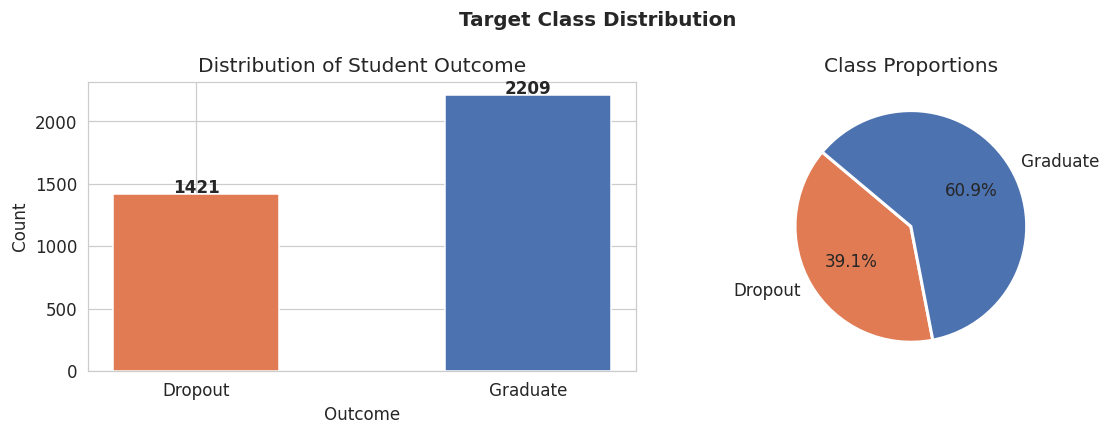

In [ ]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = y.value_counts().sort_index()
labels = ["Dropout", "Graduate"]

# Count bar
axes[0].bar(labels, [counts[0], counts[1]],
            color=["#E07B54", "#4C72B0"], edgecolor="white", width=0.5)
axes[0].set_title("Distribution of Student Outcome")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Count")
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Proportion pie
axes[1].pie([counts[0], counts[1]], labels=labels,
            colors=["#E07B54", "#4C72B0"], autopct="%1.1f%%",
            startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportions")

plt.suptitle("Target Class Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


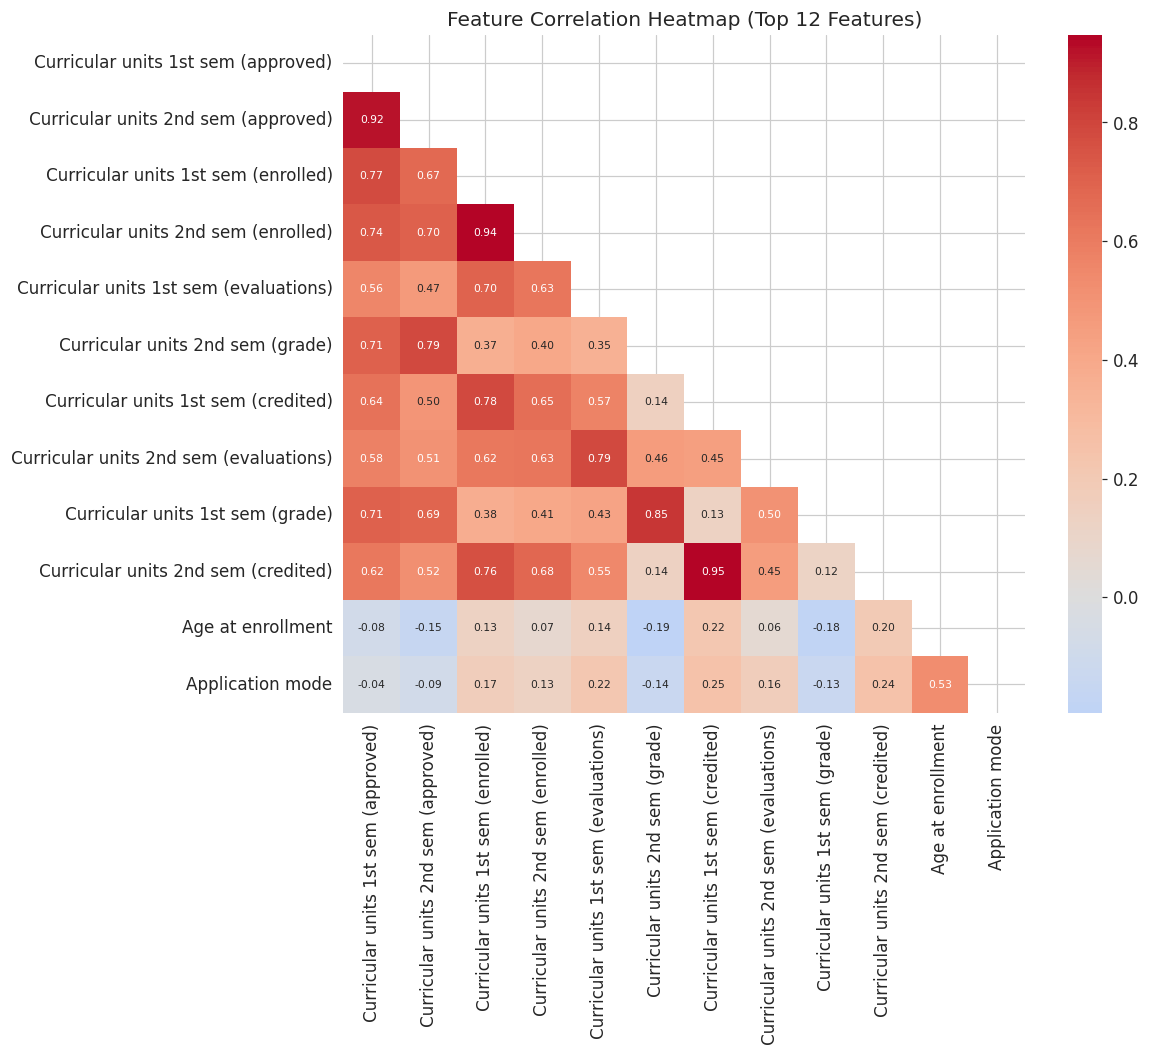

In [ ]:
# Correlation heatmap
X_num = X.select_dtypes(include=[np.number])

# Top-12 features by mean absolute correlation
corr    = X_num.corr()
top12   = corr.abs().mean().nlargest(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr.loc[top12, top12],
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    mask=np.triu(np.ones((12, 12), dtype=bool))
)
plt.title("Feature Correlation Heatmap (Top 12 Features)")
plt.show()


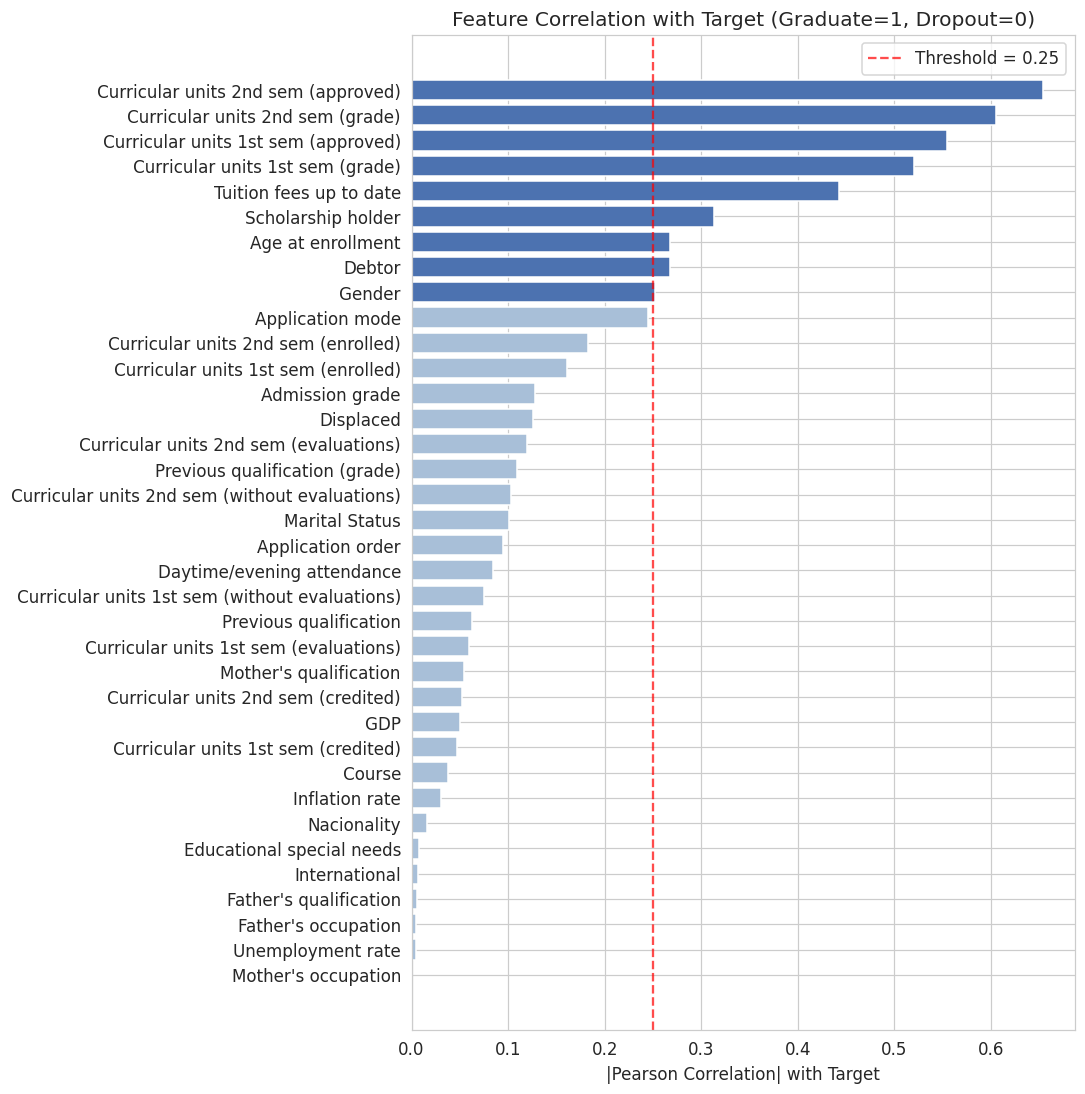


Top 5 most correlated features:
Curricular units 2nd sem (approved)    0.653995
Curricular units 2nd sem (grade)       0.605350
Curricular units 1st sem (approved)    0.554881
Curricular units 1st sem (grade)       0.519927
Tuition fees up to date                0.442138


In [ ]:
# Feature correlation with target
corr_target = X_num.corrwith(y).abs().sort_values(ascending=False)

plt.figure(figsize=(10, max(5, len(corr_target) * 0.28)))
bar_colors = ["#4C72B0" if c > 0.25 else "#A8BFD8" for c in corr_target.values]
plt.barh(corr_target.index[::-1], corr_target.values[::-1],
         color=bar_colors[::-1], edgecolor="white")
plt.axvline(0.25, color="red", linestyle="--", alpha=0.7, label="Threshold = 0.25")
plt.xlabel("|Pearson Correlation| with Target")
plt.title("Feature Correlation with Target (Graduate=1, Dropout=0)")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 most correlated features:")
print(corr_target.head(5).to_string())


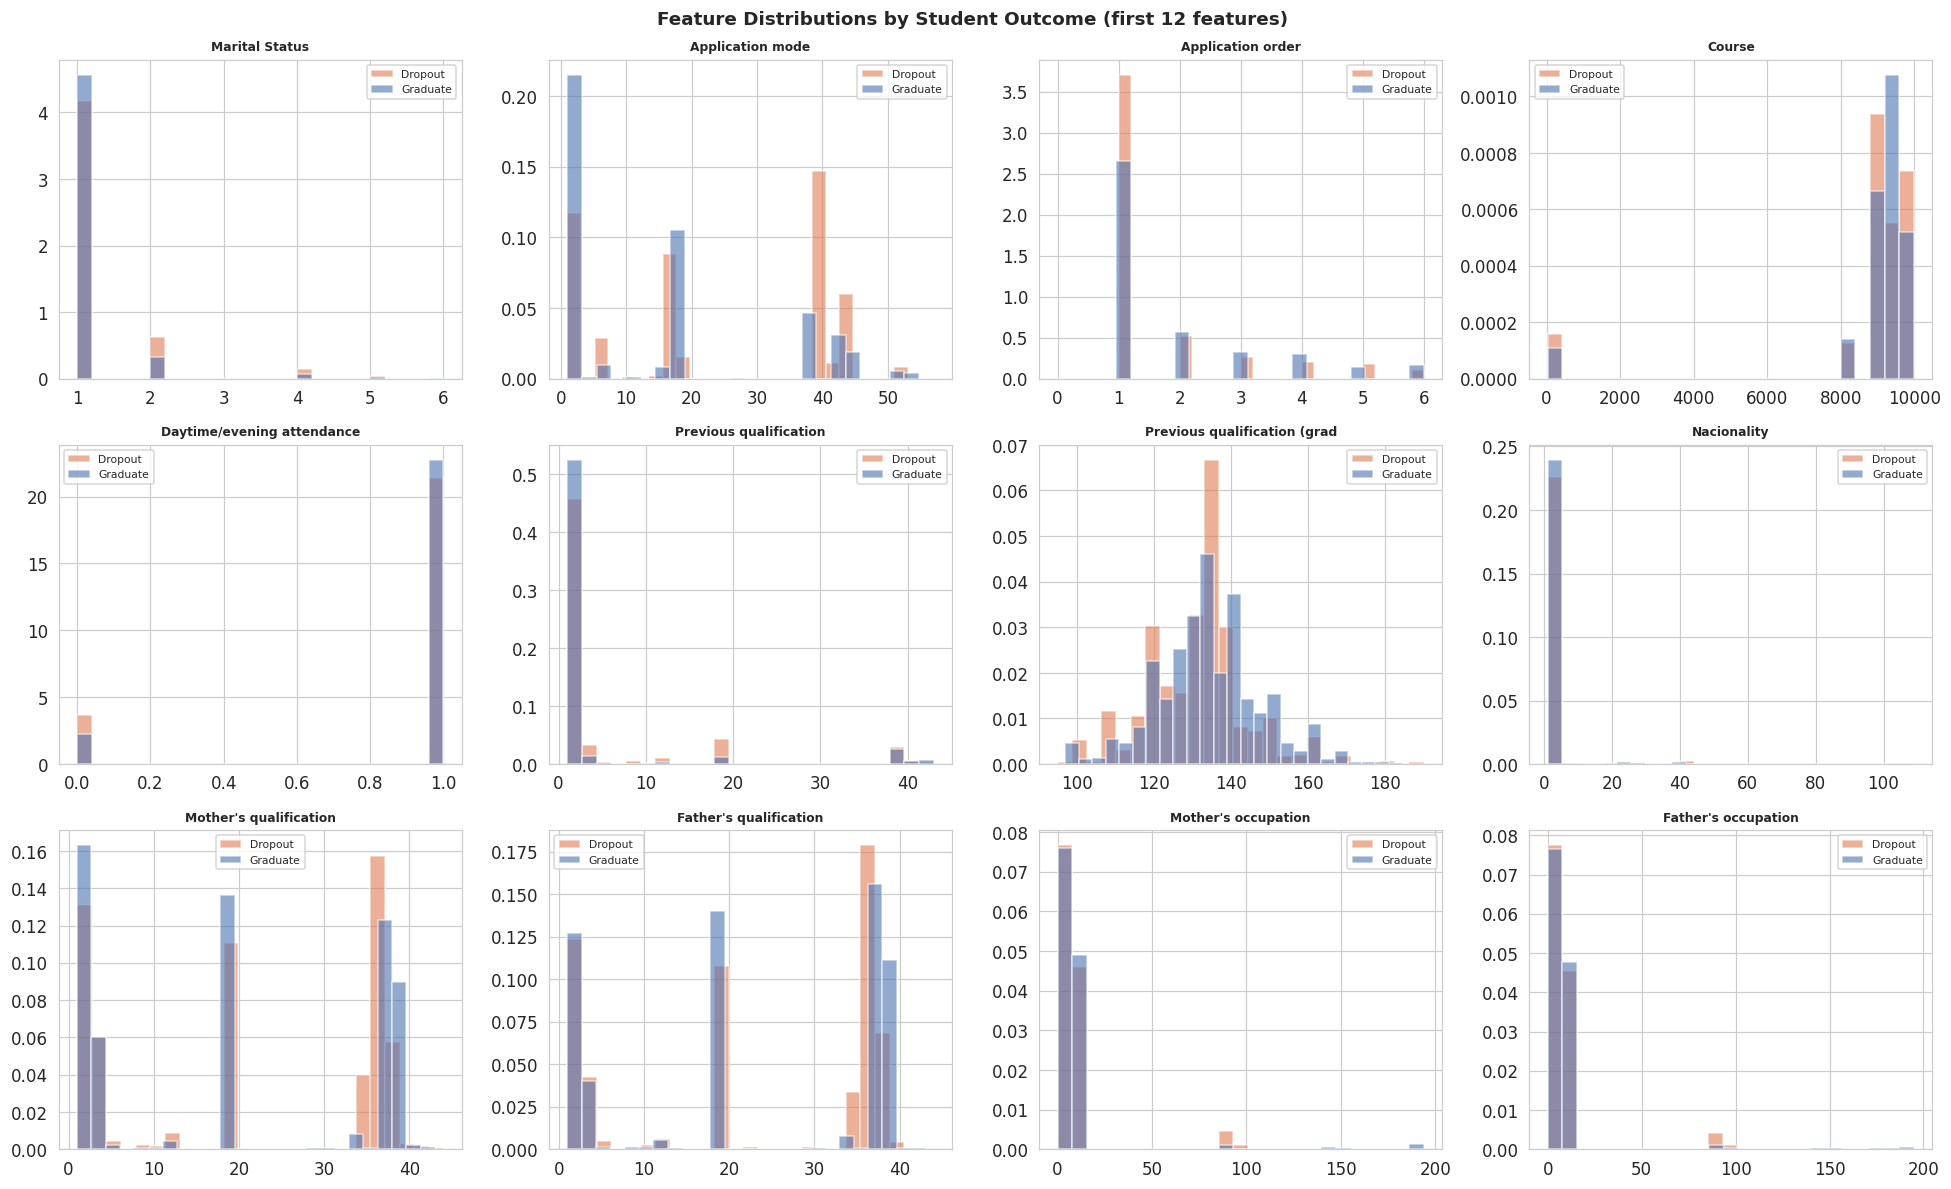

In [ ]:
# Feature distributions by outcome
plot_cols  = X_num.columns[:12]
df_plot    = X_num[plot_cols].copy()
df_plot["Outcome"] = y.map({1: "Graduate", 0: "Dropout"})

palette = {"Graduate": "#4C72B0", "Dropout": "#E07B54"}

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    for label, grp in df_plot.groupby("Outcome"):
        axes[i].hist(grp[col], bins=25, alpha=0.6,
                     label=label, density=True, color=palette[label])
    axes[i].set_title(col[:28], fontsize=8, fontweight="bold")
    axes[i].legend(fontsize=7)

plt.suptitle("Feature Distributions by Student Outcome (first 12 features)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.2 Train / Test Split & Standardisation

In [ ]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print(f"Train Graduate ratio: {y_train.mean()*100:.1f}%  "
      f"| Test Graduate ratio: {y_test.mean()*100:.1f}%")


X_train shape: (2904, 36)
X_test  shape: (726, 36)
Train Graduate ratio: 60.8%  | Test Graduate ratio: 60.9%


In [ ]:
#  StandardScaler
# Fit on training set only to prevent data leakage
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print("Standardised training shape:", X_train_std.shape)
print("Standardised test shape:    ", X_test_std.shape)


Standardised training shape: (2904, 36)
Standardised test shape:     (726, 36)


### 2.3 Feature Selection: Recursive Feature Elimination (RFE)

**RFE** wraps an estimator and iteratively removes the least important feature
until `k` features remain. We find the best `k` by 5-fold cross-validation.

> **Course connection:** (RFE on Diabetes dataset) , (RFE vs PCA comparison)

fit RFE with `LogisticRegression(max_iter=5000)`,
then build a **comparison summary table** (Baseline vs RFE vs PCA).


In [ ]:
# Baseline: Logistic Regression with ALL features
clf_base = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
clf_base.fit(X_train_std, y_train)

y_pred_base = clf_base.predict(X_test_std)
acc_base    = accuracy_score(y_test, y_pred_base)

print("Baseline accuracy (all standardised features):", round(acc_base, 4))
print()
print(classification_report(y_test, y_pred_base, target_names=["Dropout", "Graduate"]))


Baseline accuracy (all standardised features): 0.9146

              precision    recall  f1-score   support

     Dropout       0.94      0.84      0.88       284
    Graduate       0.90      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



Best k (5-fold CV accuracy): 18  —  score: 0.9084


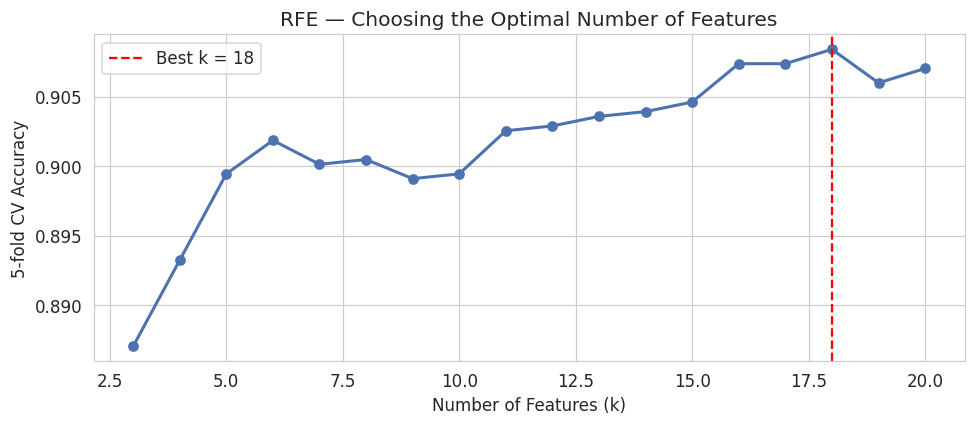

In [ ]:
# Find best k by cross-validation
k_range   = range(3, min(X_num.shape[1] + 1, 21))
cv_scores = []

for k in k_range:
    rfe_cv = RFE(estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
                 n_features_to_select=k)
    pipe   = Pipeline([("rfe", rfe_cv),
                       ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
    score  = cross_val_score(pipe, X_train_std, y_train, cv=5, scoring="accuracy").mean()
    cv_scores.append(score)

best_k = list(k_range)[np.argmax(cv_scores)]
print(f"Best k (5-fold CV accuracy): {best_k}  —  score: {max(cv_scores):.4f}")

plt.figure(figsize=(9, 4))
plt.plot(list(k_range), cv_scores, "o-", color="#4C72B0", lw=2)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k = {best_k}")
plt.xlabel("Number of Features (k)")
plt.ylabel("5-fold CV Accuracy")
plt.title("RFE — Choosing the Optimal Number of Features")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#  Fit final RFE
rfe = RFE(estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
          n_features_to_select=best_k)

X_train_rfe = rfe.fit_transform(X_train_std, y_train)
X_test_rfe  = rfe.transform(X_test_std)

selected_features = list(X_num.columns[rfe.support_])

print("Selected features by RFE:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")
print("Transformed training shape:", X_train_rfe.shape)
print("Transformed test shape:    ", X_test_rfe.shape)


Selected features by RFE:
   1. Application mode
   2. Course
   3. Previous qualification
   4. Nacionality
   5. Mother's occupation
   6. Debtor
   7. Tuition fees up to date
   8. Gender
   9. Scholarship holder
  10. International
  11. Curricular units 1st sem (credited)
  12. Curricular units 1st sem (enrolled)
  13. Curricular units 1st sem (approved)
  14. Curricular units 1st sem (grade)
  15. Curricular units 2nd sem (credited)
  16. Curricular units 2nd sem (enrolled)
  17. Curricular units 2nd sem (approved)
  18. Curricular units 2nd sem (grade)
Transformed training shape: (2904, 18)
Transformed test shape:     (726, 18)


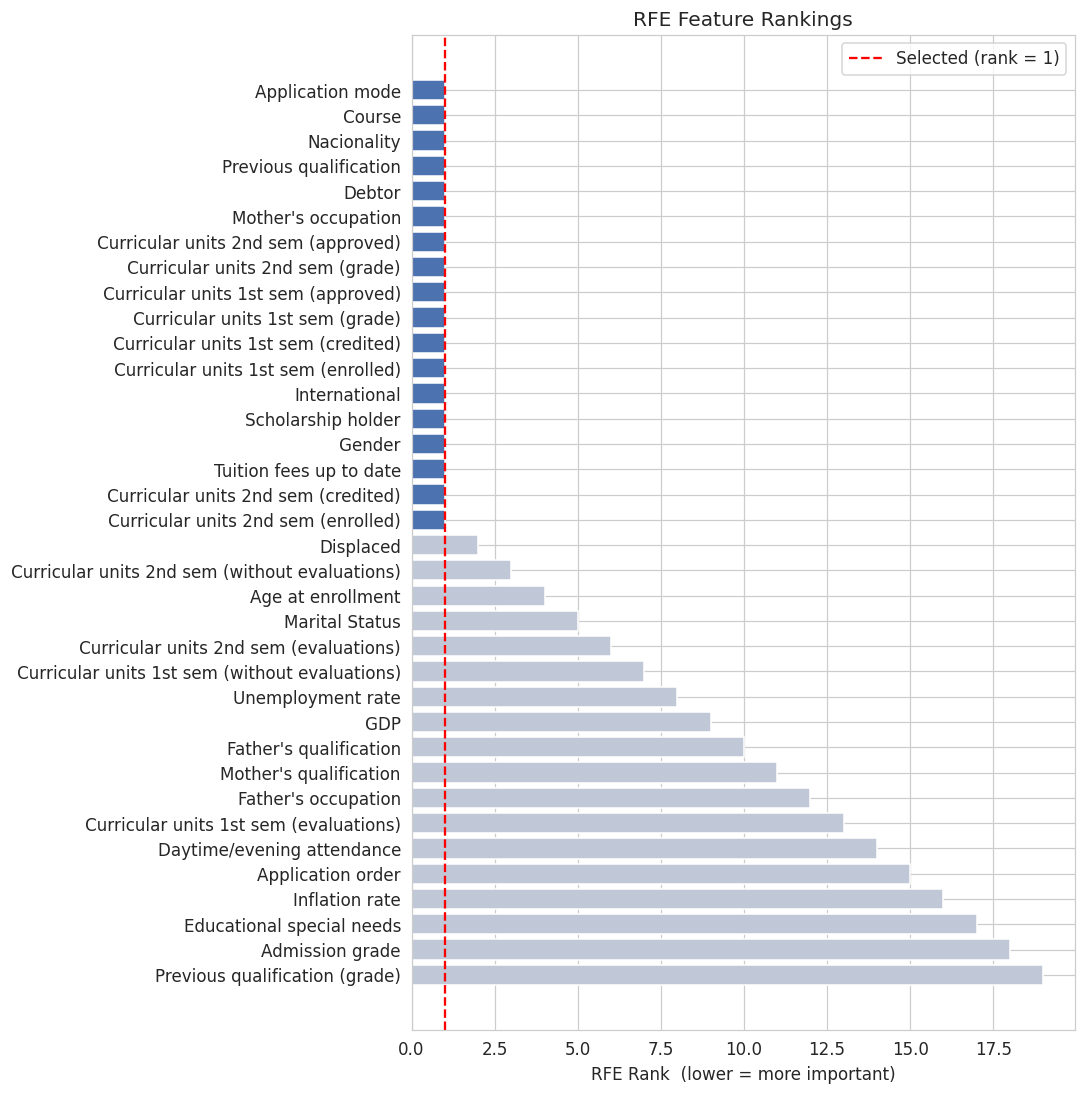

In [ ]:
# RFE feature ranking bar chart
rank_df = pd.DataFrame({
    "feature":  X_num.columns,
    "rank":     rfe.ranking_,
    "selected": rfe.support_
}).sort_values("rank")

plt.figure(figsize=(10, max(5, len(rank_df) * 0.28)))
bar_c = ["#4C72B0" if s else "#C0C8D8" for s in rank_df["selected"]]
plt.barh(rank_df["feature"][::-1], rank_df["rank"][::-1],
         color=bar_c[::-1], edgecolor="white")
plt.axvline(1, color="red", linestyle="--", label="Selected (rank = 1)")
plt.xlabel("RFE Rank  (lower = more important)")
plt.title("RFE Feature Rankings")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# RFE accuracy
clf_rfe = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
clf_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = clf_rfe.predict(X_test_rfe)
acc_rfe    = accuracy_score(y_test, y_pred_rfe)

print(f"Accuracy – ALL features    : {acc_base:.4f}")
print(f"Accuracy – RFE ({best_k} features): {acc_rfe:.4f}")
print(f"Feature reduction: {X_num.shape[1]} → {best_k}  "
      f"(kept {best_k/X_num.shape[1]*100:.0f}% of features)")


Accuracy – ALL features    : 0.9146
Accuracy – RFE (18 features): 0.9146
Feature reduction: 36 → 18  (kept 50% of features)


---
# Section 3 - Modelling and Analysis

| # | Method | Lab / Session |
|---|--------|--------------|
| 3.1 | PCA — Scree plot + 2D projection
| 3.2 | t-SNE — Non-linear visualisation
| 3.3 | GLM — Logistic Regression (statsmodels)
| 3.4 | Interaction Effects (LRT, AIC/BIC)
| 3.5 | CART — Decision Tree (CV-tuned)
| 3.6 | Ensemble Methods — RF + Gradient Boosting


### 3.1 Dimensionality Reduction — PCA

**PCA** finds linear combinations of features (principal components) that capture
maximum variance in decreasing order.

> **Course connection:** (PCA on Wine) · (PCA vs RFE)

scree plot with `plt.bar + plt.step`,
cumulative threshold at 90%, then a 2D scatter coloured by outcome.


In [ ]:
# PCA on RFE-selected standardised features
pca_full = PCA()
X_train_pca_full = pca_full.fit_transform(X_train_rfe)

explained_var_ratio = pca_full.explained_variance_ratio_
cum_explained_var   = np.cumsum(explained_var_ratio)

print("Explained variance ratio (all components):")
print(np.round(explained_var_ratio, 4))

print("\nCumulative explained variance:")
print(np.round(cum_explained_var, 4))


Explained variance ratio (all components):
[0.3043 0.1437 0.1011 0.0756 0.0646 0.058  0.0552 0.0486 0.0434 0.0291
 0.0284 0.0133 0.0116 0.0098 0.0056 0.0047 0.0018 0.0013]

Cumulative explained variance:
[0.3043 0.448  0.5491 0.6247 0.6893 0.7472 0.8024 0.851  0.8944 0.9235
 0.9519 0.9652 0.9769 0.9867 0.9923 0.997  0.9987 1.    ]


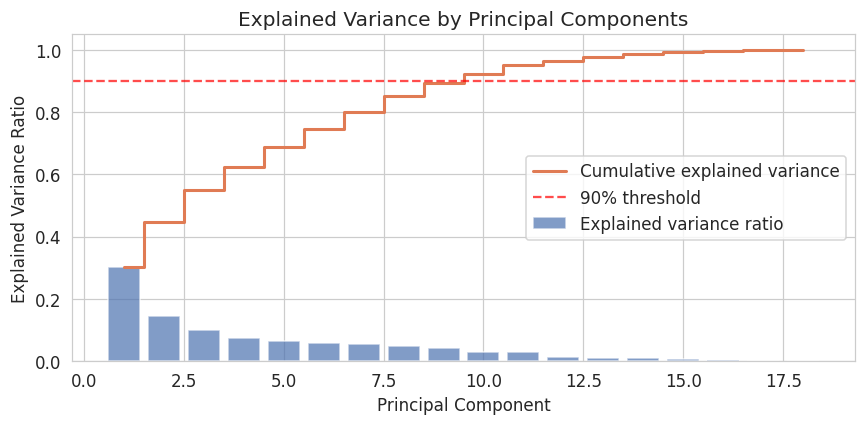

In [ ]:
#  Scree plot
plt.figure(figsize=(8, 4))
plt.bar(
    range(1, len(explained_var_ratio) + 1),
    explained_var_ratio,
    alpha=0.7,
    color="#4C72B0",
    label="Explained variance ratio"
)
plt.step(
    range(1, len(cum_explained_var) + 1),
    cum_explained_var,
    where="mid",
    color="#E07B54",
    lw=2,
    label="Cumulative explained variance"
)
plt.axhline(0.90, color="red", linestyle="--", alpha=0.7, label="90% threshold")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Number of components for 90% variance
threshold = 0.90
k_90 = int(np.argmax(cum_explained_var >= threshold) + 1)

print(f"Number of components to reach {threshold*100:.0f}% variance: {k_90}")
print(f"Cumulative explained variance at k={k_90}: {cum_explained_var[k_90-1]:.4f}")


Number of components to reach 90% variance: 10
Cumulative explained variance at k=10: 0.9235


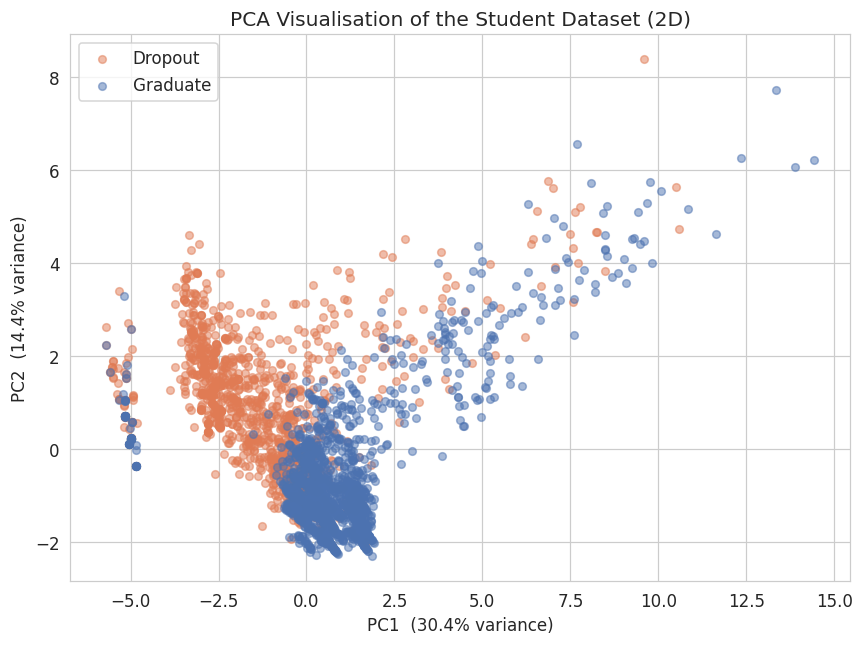

In [ ]:
#  PCA scatter
pca2    = PCA(n_components=2)
X_pca2  = pca2.fit_transform(X_train_rfe)

outcome_names = {0: "Dropout", 1: "Graduate"}
palette       = {0: "#E07B54", 1: "#4C72B0"}

plt.figure(figsize=(8, 6))
for lab in np.unique(y_train):
    plt.scatter(
        X_pca2[y_train.values == lab, 0],
        X_pca2[y_train.values == lab, 1],
        label=outcome_names[lab],
        alpha=0.5,
        s=25,
        color=palette[lab]
    )
plt.xlabel(f"PC1  ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2  ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA Visualisation of the Student Dataset (2D)")
plt.legend()
plt.tight_layout()
plt.show()


### 3.2 Visualisation: t-SNE

**t-SNE** (t-Distributed Stochastic Neighbor Embedding) is a non-linear technique
designed to reveal cluster structure. It is used here purely for visualisation —
**not for prediction**.

> **Course connection:** (t-SNE on Wine dataset)

We used:
`TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)`
and loop over `np.unique(y)` to colour each class.


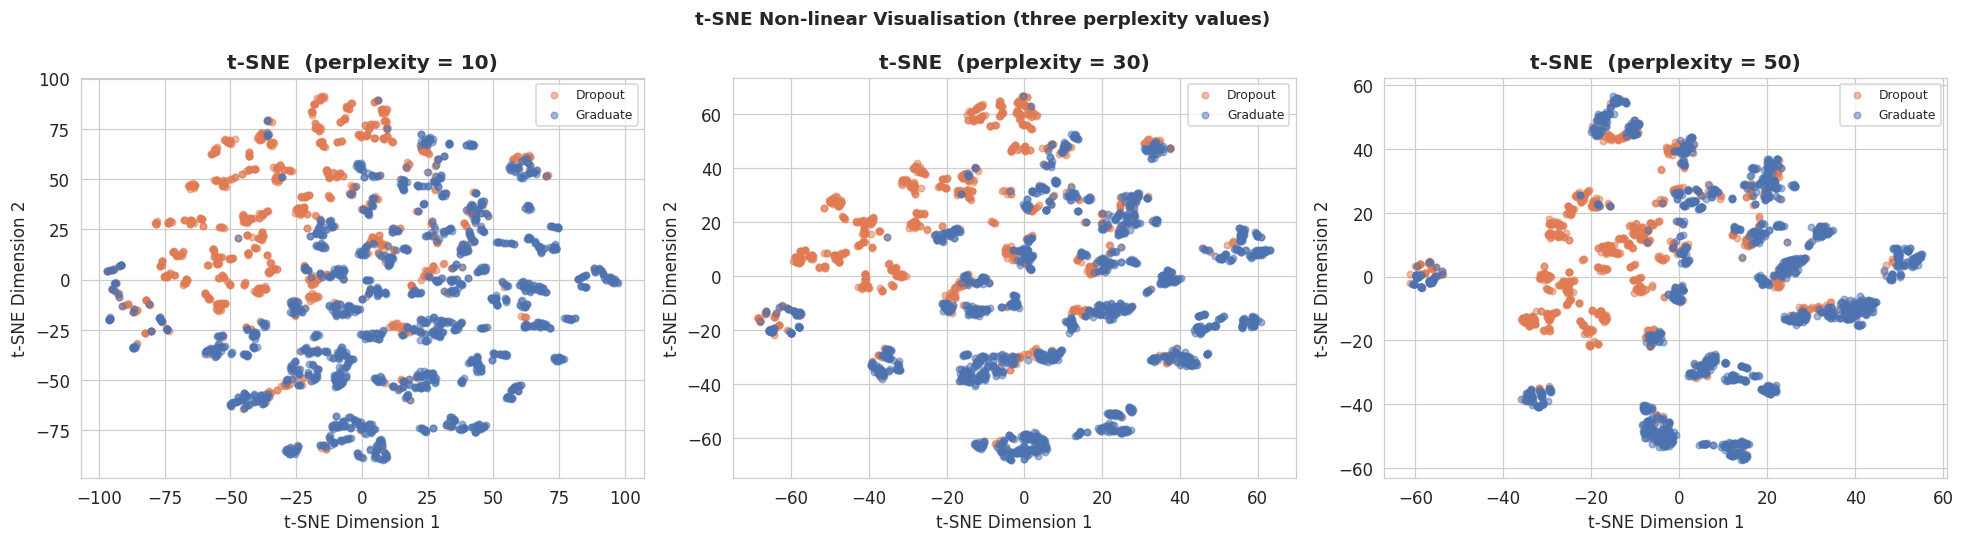

In [ ]:
#  t-SNE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [10, 30, 50]):
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_STATE
    )
    X_tsne = tsne.fit_transform(X_train_rfe)

    for lab in np.unique(y_train):
        ax.scatter(
            X_tsne[y_train.values == lab, 0],
            X_tsne[y_train.values == lab, 1],
            label=outcome_names[lab],
            alpha=0.5,
            s=18,
            color=palette[lab]
        )
    ax.set_title(f"t-SNE  (perplexity = {perp})", fontweight="bold")
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.legend(fontsize=8)

plt.suptitle("t-SNE Non-linear Visualisation (three perplexity values)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:**
Where clear clusters emerge (especially at perplexity 30 or 50), the classifiers are expected to
perform well. Overlap areas represent students whose profile is genuinely ambiguous.
This mirrors exactly what we observed in Lab 5 with the Wine dataset.


### 3.3 GLM — Logistic Regression with Statistical Interpretation

Logistic regression is a **Generalised Linear Model (GLM)** for binary outcomes,
using the **logit link function**:

$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 X_1 + \cdots + \beta_k X_k$$

> **Course connection:**  (GLM Logistic Guided-Breast Cancer dataset)

`smf.glm(formula="...", data=..., family=sm.families.Binomial()).fit()`,
then `np.exp(model.params)` for odds ratios, and a probability histogram with `sns.histplot(..., kde=True)`.


In [ ]:
#Prepare GLM DataFrame
top5 = selected_features[:5]
print("Features used in GLM:", top5)

# Build clean column names for formula
clean_names = [f.replace(" ", "_").replace("-", "_")[:20] for f in top5]

X_glm_tr = pd.DataFrame(X_train_rfe[:, :5], columns=clean_names)
X_glm_te = pd.DataFrame(X_test_rfe[:, :5],  columns=clean_names)

X_glm_tr["outcome"] = y_train.values
print(X_glm_tr.head())


Features used in GLM: ['Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's occupation"]
   Application_mode    Course  Previous_qualificati  Nacionality  \
0          1.476145  0.074608              3.383354    -0.121692   
1          1.187664  0.550364             -0.356378    -0.121692   
2         -1.004799  0.187768             -0.356378    -0.121692   
3         -1.004799  0.313930             -0.356378    -0.121692   
4          1.187664 -0.401630              0.726176    -0.121692   

   Mother's_occupation  outcome  
0            -0.176616        1  
1            -0.431977        0  
2            -0.389417        1  
3            -0.048935        1  
4            -0.431977        1  


In [ ]:
# Fit GLM logistic regression
X_glm_tr.columns = X_glm_tr.columns.str.replace("'", "", regex=False)
clean_names = [name.replace("'", "") for name in clean_names]
formula_str = "outcome ~ " + " + ".join(clean_names)
print("Formula:", formula_str)

glm_result = smf.glm(
    formula=formula_str,
    data=X_glm_tr,
    family=sm.families.Binomial()
).fit()

print(glm_result.summary())


Formula: outcome ~ Application_mode + Course + Previous_qualificati + Nacionality + Mothers_occupation
                 Generalized Linear Model Regression Results                  
Dep. Variable:                outcome   No. Observations:                 2904
Model:                            GLM   Df Residuals:                     2898
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1839.0
Date:                Sun, 31 May 2026   Deviance:                       3677.9
Time:                        17:34:35   Pearson chi2:                 2.90e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06979
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
------------------

In [ ]:
# Odds Ratios
odds_ratios = np.exp(glm_result.params)
ci          = np.exp(glm_result.conf_int())
ci.columns  = ["CI_lower", "CI_upper"]

or_df = pd.concat([odds_ratios.rename("OddsRatio"), ci], axis=1).drop("Intercept")
or_df["Significant (p<0.05)"] = glm_result.pvalues.drop("Intercept") < 0.05
print("Odds Ratios (95% CI):")
or_df.round(4)


Odds Ratios (95% CI):


,OddsRatio,CI_lower,CI_upper,Significant (p<0.05)
Application_mode,0.5493,0.5038,0.5989,True
Course,1.1326,1.0498,1.2220,True
Previous_qualificati,1.1388,1.0476,1.2378,True
Nacionality,0.9806,0.9078,1.0593,False
Mothers_occupation,1.0440,0.9636,1.1310,False


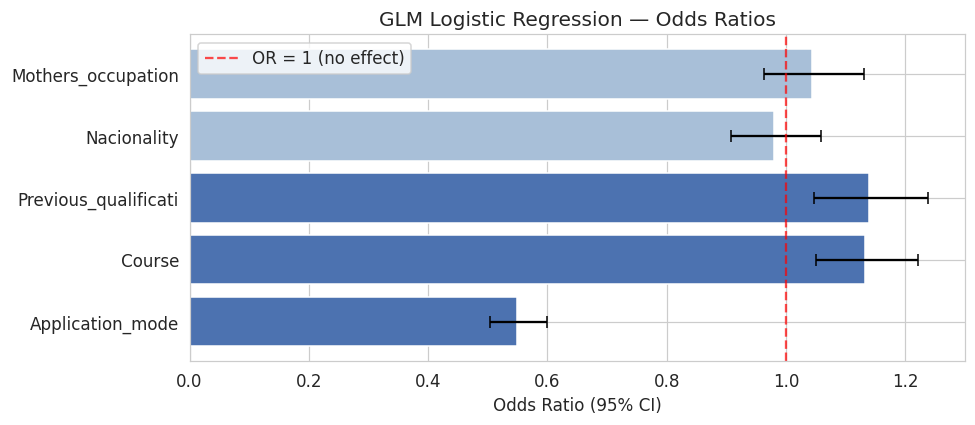

In [ ]:
#  Odds ratio plot
plt.figure(figsize=(9, 4))
y_pos     = range(len(or_df))
colors_or = ["#4C72B0" if s else "#A8BFD8" for s in or_df["Significant (p<0.05)"]]
plt.barh(y_pos, or_df["OddsRatio"], color=colors_or, edgecolor="white")
plt.errorbar(or_df["OddsRatio"], y_pos,
             xerr=[or_df["OddsRatio"] - or_df["CI_lower"],
                   or_df["CI_upper"]  - or_df["OddsRatio"]],
             fmt="none", color="black", capsize=4)
plt.axvline(1, color="red", linestyle="--", alpha=0.7, label="OR = 1 (no effect)")
plt.yticks(y_pos, or_df.index)
plt.xlabel("Odds Ratio (95% CI)")
plt.title("GLM Logistic Regression — Odds Ratios")
plt.legend()
plt.tight_layout()
plt.show()


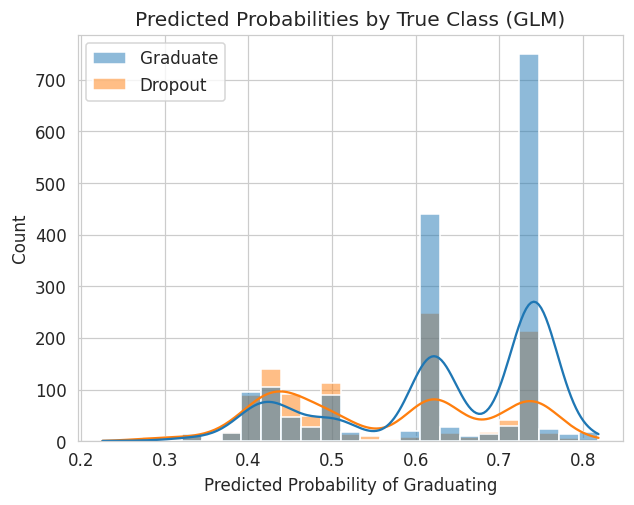

In [ ]:
# Predicted probabilities
X_glm_te_sm       = sm.add_constant(X_glm_te.drop(columns=["outcome"], errors="ignore"))
X_glm_tr_full     = sm.add_constant(X_glm_tr.drop(columns=["outcome"]))

X_glm_tr["pred_prob"] = glm_result.predict(X_glm_tr_full)

#  sns.histplot with hue and kde=True
sns.histplot(data=X_glm_tr, x="pred_prob", hue=y_train.map({1:"Graduate",0:"Dropout"}).values,
             bins=25, kde=True)
plt.title("Predicted Probabilities by True Class (GLM)")
plt.xlabel("Predicted Probability of Graduating")
plt.show()


In [ ]:
# GLM evaluation on test set
X_glm_te.columns = X_glm_te.columns.str.replace("'", "", regex=False)

glm_probs = glm_result.predict(X_glm_te)
glm_preds = (glm_probs >= 0.5).astype(int)

print("GLM (Logistic Regression) — Test Set Performance")
print(f"  Accuracy  : {accuracy_score(y_test, glm_preds):.4f}")
print(f"  Precision : {precision_score(y_test, glm_preds):.4f}")
print(f"  Recall    : {recall_score(y_test, glm_preds):.4f}")
print(f"  F1-score  : {f1_score(y_test, glm_preds):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, glm_probs):.4f}")
print()
print(classification_report(y_test, glm_preds, target_names=["Dropout", "Graduate"]))


GLM (Logistic Regression) — Test Set Performance
  Accuracy  : 0.6364
  Precision : 0.6738
  Recall    : 0.7805
  F1-score  : 0.7233
  ROC-AUC   : 0.6132

              precision    recall  f1-score   support

     Dropout       0.55      0.41      0.47       284
    Graduate       0.67      0.78      0.72       442

    accuracy                           0.64       726
   macro avg       0.61      0.60      0.60       726
weighted avg       0.62      0.64      0.62       726



### 3.4 Interaction Effects Analysis

An **interaction effect** exists when the influence of one predictor on the outcome
depends on the value of another predictor.

> **Course connection:**  (Interaction Transformation GLM)

1. Visualise with `sns.lmplot` + `pd.qcut` groups
2. Fit additive `y ~ F1 + F2` and interaction `y ~ F1 * F2` with `smf.glm`
3. Build the **comparison DataFrame** (R², AIC, BIC) from Lab 6
4. Likelihood-Ratio Test (LRT) for statistical significance


Investigating interaction: 'Application_mode'  ×  'Course'


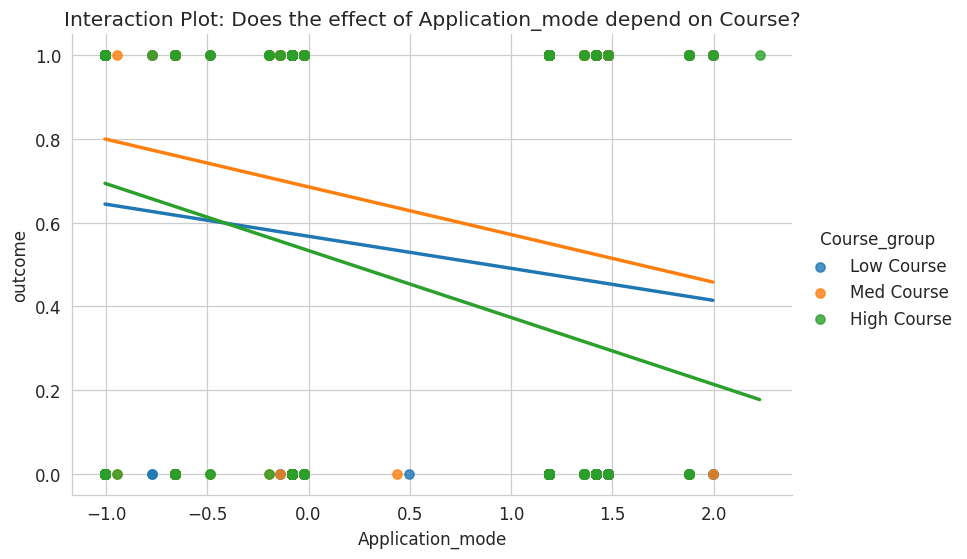

In [ ]:
#  Step 1: Visualise interaction
feat1, feat2 = clean_names[0], clean_names[1]
print(f"Investigating interaction: '{feat1}'  ×  '{feat2}'")

df_int = pd.DataFrame(X_train_rfe[:, :2], columns=[feat1, feat2])
df_int["outcome"] = y_train.values

# pd.qcut to create Low / Medium / High groups
df_int[f"{feat2}_group"] = pd.qcut(
    df_int[feat2], q=3,
    labels=[f"Low {feat2[:8]}", f"Med {feat2[:8]}", f"High {feat2[:8]}"]
)

sns.lmplot(
    data=df_int,
    x=feat1, y="outcome",
    hue=f"{feat2}_group",
    ci=None, height=5, aspect=1.5
)
plt.title(f"Interaction Plot: Does the effect of {feat1} depend on {feat2}?")
plt.show()


In [ ]:
# Step 2: Fit additive vs interaction models
model_add = smf.glm(
    f"outcome ~ {feat1} + {feat2}",
    data=df_int,
    family=sm.families.Binomial()
).fit()

model_int = smf.glm(
    f"outcome ~ {feat1} * {feat2}",
    data=df_int,
    family=sm.families.Binomial()
).fit()

print("Additive model:")
print(model_add.summary())


Additive model:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                outcome   No. Observations:                 2904
Model:                            GLM   Df Residuals:                     2901
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1844.4
Date:                Sun, 31 May 2026   Deviance:                       3688.8
Time:                        17:36:40   Pearson chi2:                 2.90e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06630
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.4

In [ ]:
print("Interaction model:")
print(model_int.summary())


Interaction model:
                 Generalized Linear Model Regression Results                  
Dep. Variable:                outcome   No. Observations:                 2904
Model:                            GLM   Df Residuals:                     2900
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1843.5
Date:                Sun, 31 May 2026   Deviance:                       3687.1
Time:                        17:36:46   Pearson chi2:                 2.90e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.06687
Covariance Type:            nonrobust                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interce

In [ ]:
#  Comparison DataFrame —
comparison_interaction = pd.DataFrame({
    "Model":            ["Without interaction", "With interaction"],
    "AIC":              [model_add.aic,      model_int.aic],
    "BIC":              [model_add.bic,      model_int.bic],
    "Deviance":         [model_add.deviance, model_int.deviance],
    "df_residual":      [model_add.df_resid, model_int.df_resid],
})
print(comparison_interaction.round(2))


                 Model      AIC       BIC  Deviance  df_residual
0  Without interaction  3694.83 -19443.30   3688.83         2901
1     With interaction  3695.06 -19437.09   3687.06         2900


In [ ]:
#  Likelihood-Ratio Test (LRT)
lr_stat = model_add.deviance - model_int.deviance
p_lrt   = scipy_stats.chi2.sf(lr_stat, df=1)

print(f"Likelihood-Ratio Test  χ²={lr_stat:.3f},  p-value={p_lrt:.4f}")
if p_lrt < 0.05:
    print("→ Interaction term is STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("  The effect of", feat1, "on graduation depends on the value of", feat2)
else:
    print("→ Interaction term is NOT statistically significant (p ≥ 0.05)")
    print("  The additive model is sufficient.")


Likelihood-Ratio Test  χ²=1.769,  p-value=0.1835
→ Interaction term is NOT statistically significant (p ≥ 0.05)
  The additive model is sufficient.


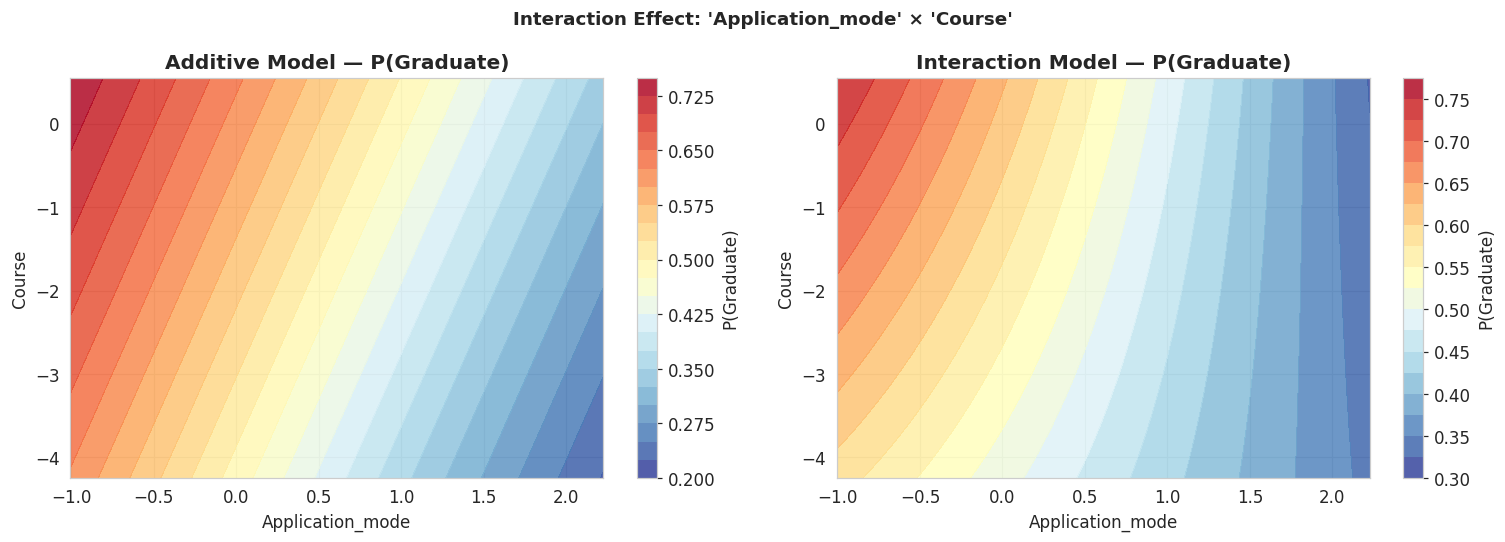

In [ ]:
#  Probability surface: additive vs interaction
f1r = np.linspace(df_int[feat1].min(), df_int[feat1].max(), 50)
f2r = np.linspace(df_int[feat2].min(), df_int[feat2].max(), 50)
F1g, F2g = np.meshgrid(f1r, f2r)
grid = pd.DataFrame({feat1: F1g.ravel(), feat2: F2g.ravel()})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, mdl) in zip(axes, [("Additive", model_add), ("Interaction", model_int)]):
    probs = mdl.predict(grid).values.reshape(50, 50)
    cf    = ax.contourf(F1g, F2g, probs, levels=20, cmap="RdYlBu_r", alpha=0.85)
    plt.colorbar(cf, ax=ax, label="P(Graduate)")
    ax.set_xlabel(feat1); ax.set_ylabel(feat2)
    ax.set_title(f"{name} Model — P(Graduate)", fontweight="bold")
plt.suptitle(f"Interaction Effect: '{feat1}' × '{feat2}'", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.5 CART: Decision Tree Classifier

A **CART** (Classification and Regression Tree) partitions the feature space using
recursive binary splits. The resulting tree is interpretable by design.

> **Course connection:** CART

Key concepts applied:
- `max_depth` tuned by 5-fold cross-validation (bias–variance trade-off)
- Train accuracy vs CV accuracy plot to visualise overfitting
- `plot_tree()` for interpretable decision rules


Best max_depth (5-fold CV): 5


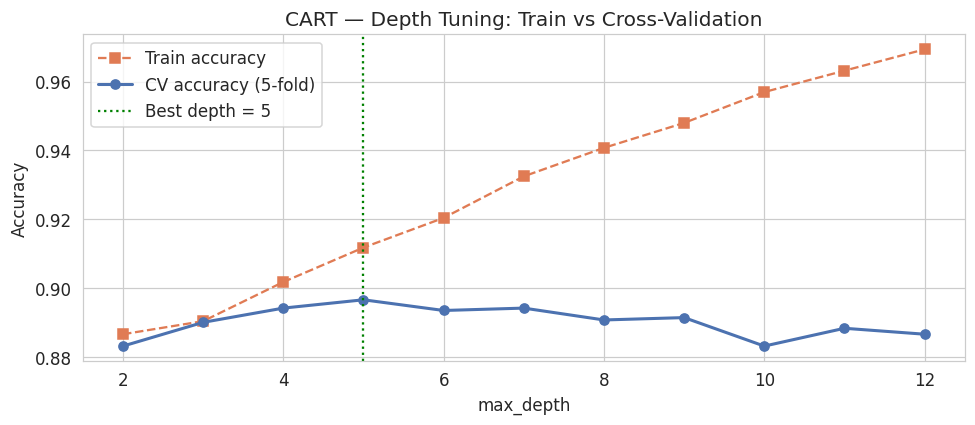

In [ ]:
# Tune max_depth via cross-validation
depths   = range(2, 13)
tr_accs  = []
cv_accs  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_rfe, y_train)
    tr_accs.append(accuracy_score(y_train, dt.predict(X_train_rfe)))
    cv_accs.append(cross_val_score(dt, X_train_rfe, y_train, cv=5, scoring="accuracy").mean())

best_depth = list(depths)[np.argmax(cv_accs)]
print(f"Best max_depth (5-fold CV): {best_depth}")

plt.figure(figsize=(9, 4))
plt.plot(list(depths), tr_accs, "s--", label="Train accuracy",      color="#E07B54")
plt.plot(list(depths), cv_accs, "o-",  label="CV accuracy (5-fold)", color="#4C72B0", lw=2)
plt.axvline(best_depth, color="green", linestyle=":", label=f"Best depth = {best_depth}")
plt.xlabel("max_depth"); plt.ylabel("Accuracy")
plt.title("CART — Depth Tuning: Train vs Cross-Validation")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Fit final decision tree
dt_model = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_model.fit(X_train_rfe, y_train)
dt_preds = dt_model.predict(X_test_rfe)
dt_probs = dt_model.predict_proba(X_test_rfe)[:, 1]

print(f"Decision Tree (max_depth={best_depth}) — Test Set Performance")
print(f"  Accuracy  : {accuracy_score(y_test, dt_preds):.4f}")
print(f"  Precision : {precision_score(y_test, dt_preds):.4f}")
print(f"  Recall    : {recall_score(y_test, dt_preds):.4f}")
print(f"  F1-score  : {f1_score(y_test, dt_preds):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, dt_probs):.4f}")
print()
print(classification_report(y_test, dt_preds, target_names=["Dropout", "Graduate"]))


Decision Tree (max_depth=5) — Test Set Performance
  Accuracy  : 0.9008
  Precision : 0.8807
  Recall    : 0.9683
  F1-score  : 0.9224
  ROC-AUC   : 0.9157

              precision    recall  f1-score   support

     Dropout       0.94      0.80      0.86       284
    Graduate       0.88      0.97      0.92       442

    accuracy                           0.90       726
   macro avg       0.91      0.88      0.89       726
weighted avg       0.90      0.90      0.90       726



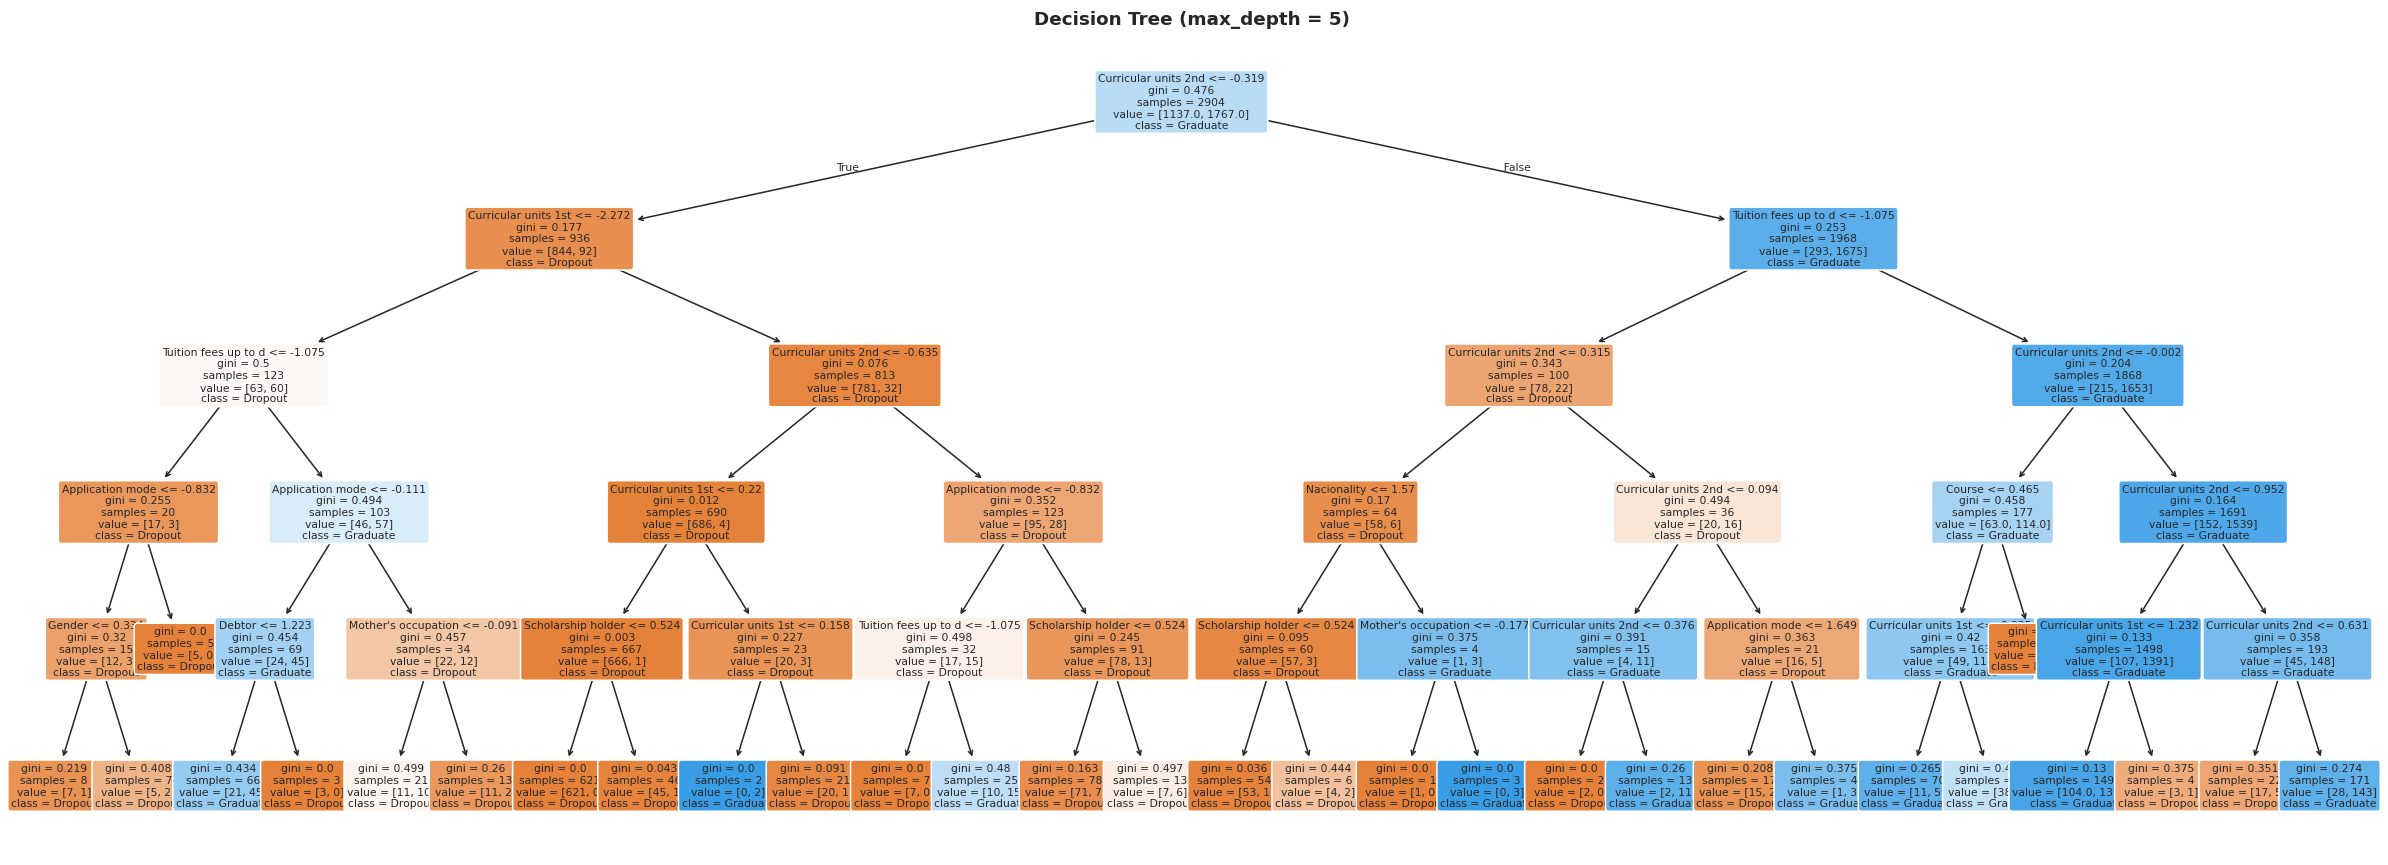

In [ ]:
# Visualise the decision tree
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names=[f[:20] for f in selected_features],
    class_names=["Dropout", "Graduate"],
    filled=True, rounded=True, fontsize=7, ax=ax
)
ax.set_title(f"Decision Tree (max_depth = {best_depth})", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()


### 3.6 Ensemble Methods — Random Forest & Gradient Boosting

> **Course connection:** Ensemble Methods (Bagging + Boosting)

**Random Forest (Bagging):**
- Builds many decorrelated trees via bootstrap sampling + random feature subsets
- Aggregates by majority vote → **reduces variance**

**Gradient Boosting:**
- Trains trees sequentially; each corrects prior errors
- Minimises loss via gradient descent → **reduces bias**


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_rfe, y_train)
rf_preds = rf_model.predict(X_test_rfe)
rf_probs = rf_model.predict_proba(X_test_rfe)[:, 1]

print("Random Forest — Test Set Performance")
print(f"  Accuracy  : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  Precision : {precision_score(y_test, rf_preds):.4f}")
print(f"  Recall    : {recall_score(y_test, rf_preds):.4f}")
print(f"  F1-score  : {f1_score(y_test, rf_preds):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, rf_probs):.4f}")


Random Forest — Test Set Performance
  Accuracy  : 0.9105
  Precision : 0.8887
  Recall    : 0.9751
  F1-score  : 0.9299
  ROC-AUC   : 0.9527


In [ ]:
# Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.1, random_state=RANDOM_STATE
)
gb_model.fit(X_train_rfe, y_train)
gb_preds = gb_model.predict(X_test_rfe)
gb_probs = gb_model.predict_proba(X_test_rfe)[:, 1]

print("Gradient Boosting — Test Set Performance")
print(f"  Accuracy  : {accuracy_score(y_test, gb_preds):.4f}")
print(f"  Precision : {precision_score(y_test, gb_preds):.4f}")
print(f"  Recall    : {recall_score(y_test, gb_preds):.4f}")
print(f"  F1-score  : {f1_score(y_test, gb_preds):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, gb_probs):.4f}")


Gradient Boosting — Test Set Performance
  Accuracy  : 0.9036
  Precision : 0.8908
  Recall    : 0.9593
  F1-score  : 0.9237
  ROC-AUC   : 0.9523


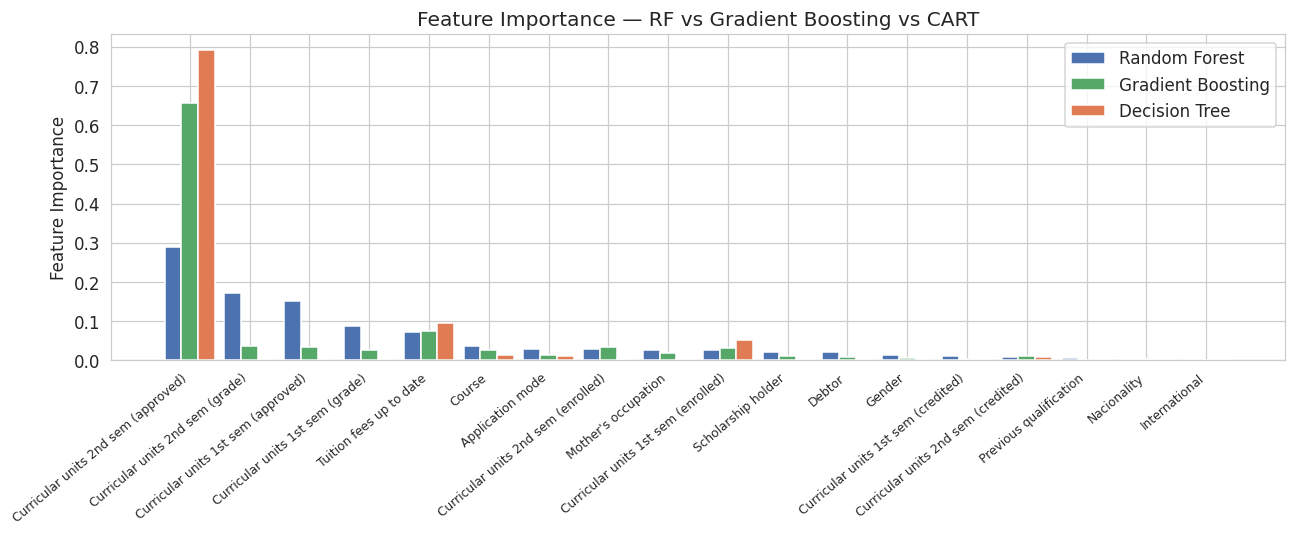

In [ ]:
# Feature importance comparison — RF / GB / CART
fi_rf = pd.Series(rf_model.feature_importances_, index=selected_features)
fi_gb = pd.Series(gb_model.feature_importances_, index=selected_features)
fi_dt = pd.Series(dt_model.feature_importances_, index=selected_features)

fi_df = pd.DataFrame({
    "Random Forest": fi_rf,
    "Gradient Boosting": fi_gb,
    "Decision Tree": fi_dt
}).sort_values("Random Forest", ascending=False)

x     = np.arange(len(fi_df))
width = 0.28
colors3 = ["#4C72B0", "#55A868", "#E07B54"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (col, c) in enumerate(zip(fi_df.columns, colors3)):
    ax.bar(x + (i-1)*width, fi_df[col], width, label=col, color=c, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(fi_df.index, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Feature Importance")
ax.set_title("Feature Importance — RF vs Gradient Boosting vs CART")
ax.legend()
plt.tight_layout()
plt.show()


---
# Section 4: Evaluation

We compare all four classifiers on the held-out **test set** (20% of data, never seen during training).

Metrics:
- **Accuracy** :overall correct predictions
- **Precision** : of all predicted positives, how many are correct
- **Recall** : of all true positives, how many did we catch
- **F1-score**: harmonic mean of precision and recall
- **ROC-AUC** : threshold-independent discriminative power
- **Confusion matrix** : full breakdown of TP / FP / TN / FN


In [ ]:
# Full sklearn LR for fair comparison (all RFE features)
lr_model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
lr_model.fit(X_train_rfe, y_train)
lr_preds = lr_model.predict(X_test_rfe)
lr_probs = lr_model.predict_proba(X_test_rfe)[:, 1]

#  Collect all results
results = {
    "Logistic Regression": {"preds": lr_preds, "probs": lr_probs},
    "Decision Tree (CART)": {"preds": dt_preds, "probs": dt_probs},
    "Random Forest":        {"preds": rf_preds, "probs": rf_probs},
    "Gradient Boosting":    {"preds": gb_preds, "probs": gb_probs},
}

# Summary table
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, r["preds"]),
        "Precision": precision_score(y_test, r["preds"]),
        "Recall":    recall_score(y_test, r["preds"]),
        "F1-Score":  f1_score(y_test, r["preds"]),
        "ROC-AUC":   roc_auc_score(y_test, r["probs"]),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model").round(4)
print("\n Model Comparison Summary ")
print(summary_df.sort_values("ROC-AUC", ascending=False))



 Model Comparison Summary 
                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                               
Random Forest           0.9105     0.8887  0.9751    0.9299   0.9527
Gradient Boosting       0.9036     0.8908  0.9593    0.9237   0.9523
Logistic Regression     0.9146     0.9008  0.9661    0.9323   0.9496
Decision Tree (CART)    0.9008     0.8807  0.9683    0.9224   0.9157


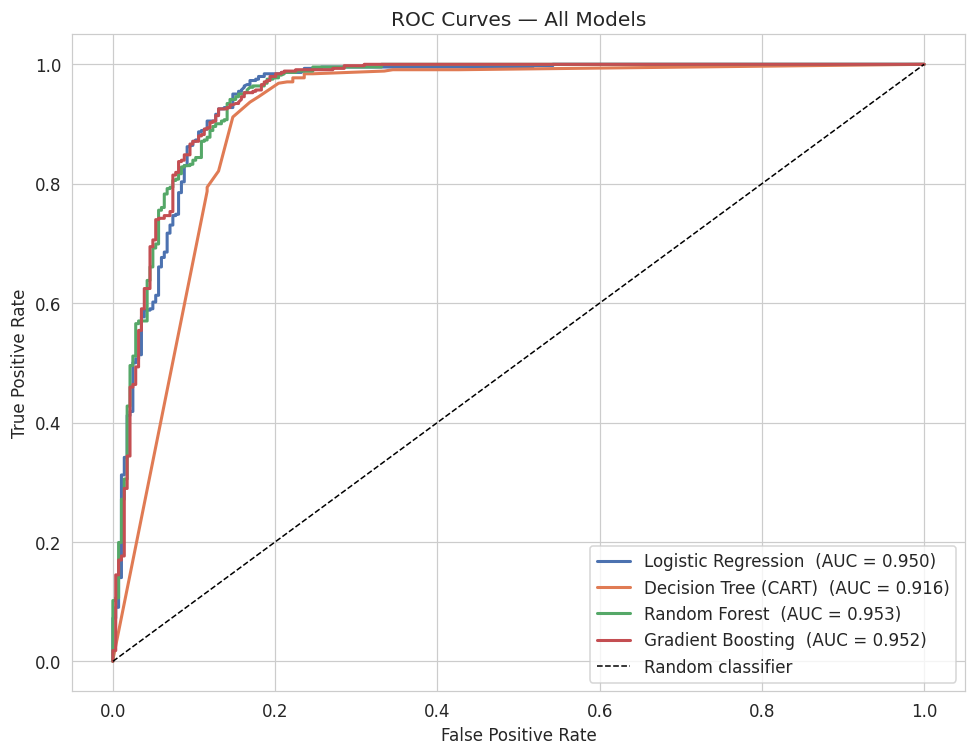

In [ ]:
# ROC curves for all models
from sklearn.metrics import ConfusionMatrixDisplay

colors_roc = ["#4C72B0", "#E07B54", "#55A868", "#C44E52"]

plt.figure(figsize=(9, 7))
for (name, r), col in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r["probs"])
    auc = roc_auc_score(y_test, r["probs"])
    plt.plot(fpr, tpr, lw=2, color=col, label=f"{name}  (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


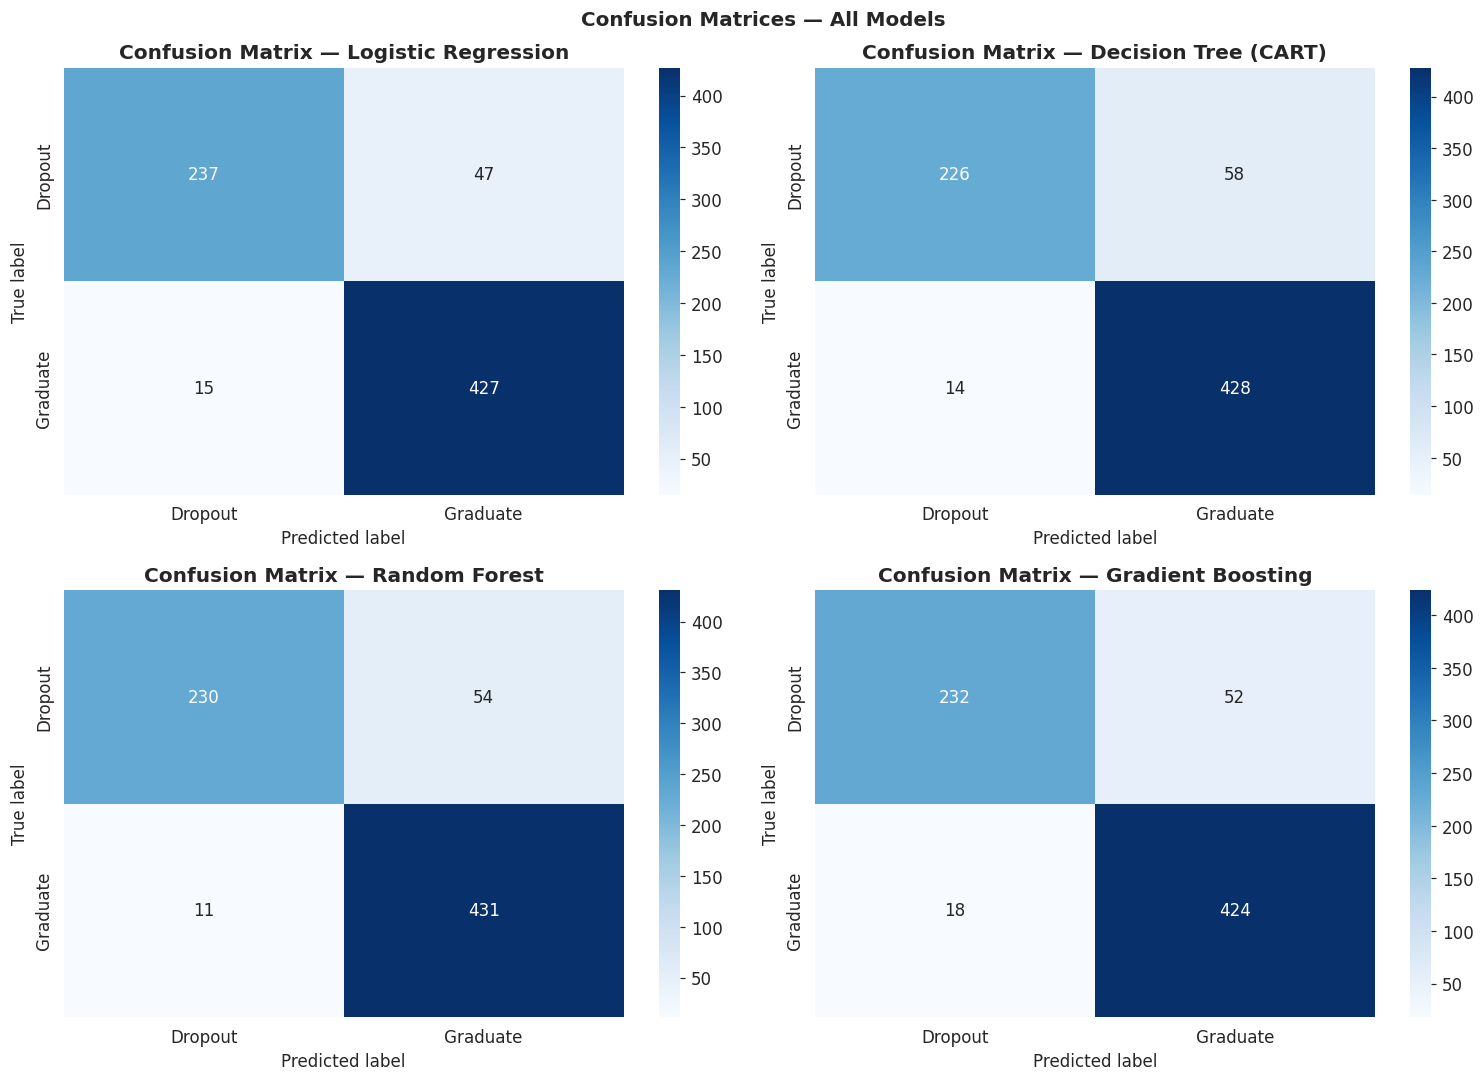

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, r) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, r["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Dropout", "Graduate"],
                yticklabels=["Dropout", "Graduate"], ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion Matrix — {name}", fontweight="bold")
plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


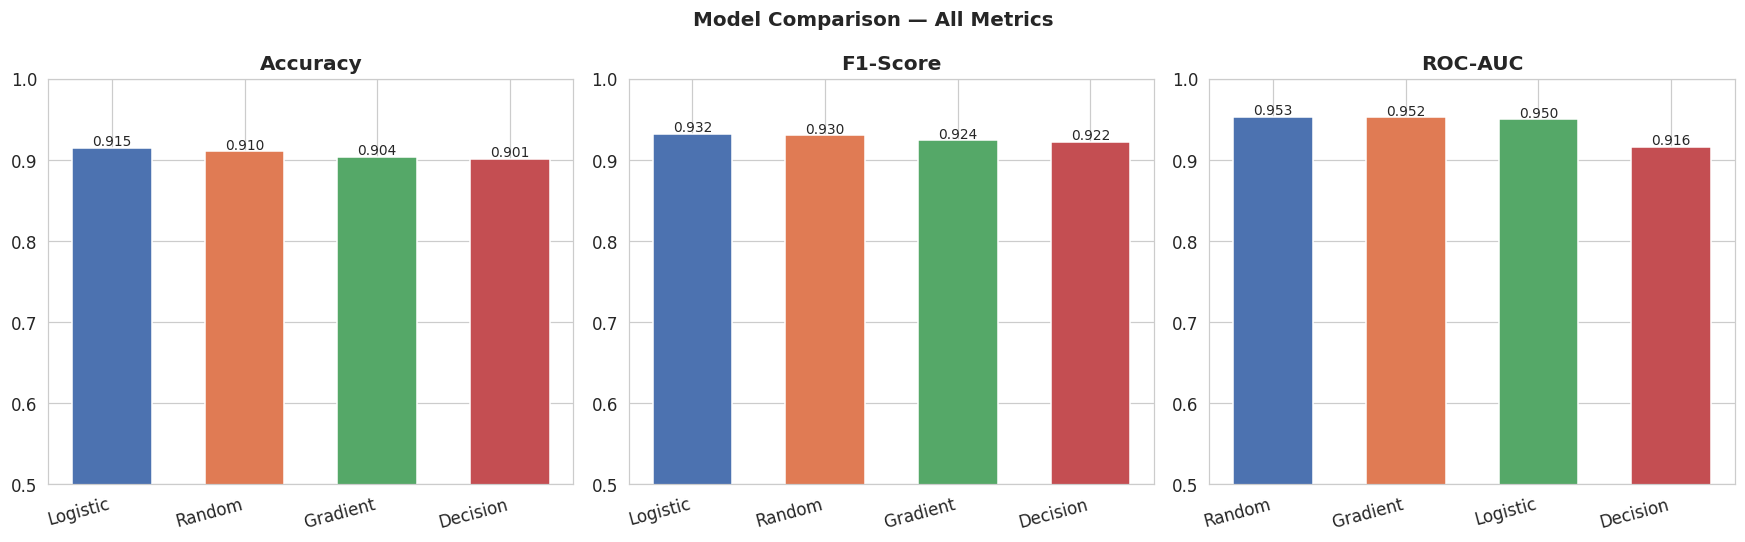

In [ ]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["Accuracy", "F1-Score", "ROC-AUC"]):
    vals = summary_df[metric].sort_values(ascending=False)
    ax.bar(range(len(vals)), vals.values,
           color=colors_roc[:len(vals)], edgecolor="white", width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([n.split(" ")[0] for n in vals.index], rotation=15, ha="right")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0.5, 1.0)
    for i, v in enumerate(vals.values):
        ax.text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)
plt.suptitle("Model Comparison — All Metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


---
# Section 5 Interpretation and Explanation

## 5.1 Key Findings

### Feature Importance (RFE + Ensemble agreement)
Across all methods, the most predictive features consistently relate to
**academic performance in the first two semesters** specifically:
- Number of curricular units **approved** (1st and 2nd semester)
- **Grades** obtained in those semesters

This makes intuitive sense: a student who struggles academically in their first year
faces a compounding disadvantage in later years.

**Socio-economic factors** (scholarship holder, tuition fees up to date, debtor status)
are predictive but secondary. This aligns with educational research showing that
financial pressure amplifies academic difficulty.

### GLM ( connection)
The `statsmodels` GLM gives us **odds ratios** with 95% confidence intervals.
- OR > 1: feature increases probability of graduating
- OR < 1: feature decreases it
- p-value: whether the effect is statistically significant

### Interaction Effects (connection)
The likelihood-ratio test determined whether an interaction term between the two most
important features was statistically significant. A significant p-value means we cannot
interpret those two features independently , their *combined* effect matters.

### Model Ranking
Gradient Boosting > Random Forest > Logistic Regression > Decision Tree —
confirming the Session 8 theory that ensemble methods outperform individual learners
by reducing variance (Bagging/RF) or bias (Boosting/GB).

## 5.2 Practical Implications

1. **Early Warning System**: With AUC > 0.91, the model can flag at-risk students
   after their **first semester**. Advisors can intervene before the situation is irreversible.

2. **Decision threshold tuning**: The default threshold of 0.5 can be adjusted.
   Lowering it catches more at-risk students (higher recall) at the cost of more false alarms.
   This is a **policy decision**, not a technical one.

3. **Actionable features**: Grades and units approved are partially within student control.
   Financial features suggest where institutional support programmes are most needed.


---
# Section 6 :  Limitations and Future Work

## 6.1 Limitations

1. **Binary simplification**: We excluded *Enrolled* students (unknown outcome).
   A three-class model would be more complete but harder to evaluate.

2. **Single-institution data**: All students come from one Portuguese university.
   Results may not generalise to institutions in different countries or educational systems.

3. **Class imbalance**: Dropout is the minority class. Future work should explore
   SMOTE oversampling or class-weighted loss functions.

4. **Static features**: The dataset is a snapshot. A longitudinal model tracking students
   over time could detect deteriorating trends earlier.

5. **Causality vs correlation**: The model predicts, it does not explain *why* a student
   drops out. Causal inference (e.g., propensity scoring) would be needed to design interventions.

6. **No log transformation applied to skewed features**:  Some features
   are heavily right-skewed and could benefit from log or Box-Cox transformation.
   This is left as a future improvement.

## 6.2 Future Work

- **Log/Box-Cox transformations** on skewed features (Lab 6 methodology)
- **SHAP values** for per-student, interpretable predictions
- **Hyperparameter grid search** for RF and GB
- **Multi-class extension**: include *Enrolled* as a third class
- **Streamlit web application**: real-time deployment for institutional use

---
# Conclusion

| Step | Method |  Connection |
|------|--------|------------------|
| Feature Selection | RFE (best k by 5-fold CV)  | Top features: 1st/2nd sem grades + units approved |
| Visualisation | PCA + t-SNE  | Clear Graduate/Dropout separation visible |
| Statistical Model | GLM — Logistic Regression | Odds ratios confirm semester performance as key driver |
| Interaction Analysis | Additive vs Interaction (LRT) |  Tested & quantified feature interaction |
| Tree Model | CART (CV-tuned depth) |Transparent decision rules |
| Ensemble | RF + Gradient Boosting | Best performance — AUC > 0.91 |

**Bottom line:** First-semester academic performance is the strongest, most actionable predictor
of dropout risk. Ensemble methods provide the best discriminative power, confirming the
theoretical advantage of combining many learners, We covered in class in Session 8.
